# AI for Medicine Project

## COVID-19 Radiography Database

This notebook builds a four-class chest X-ray classification workflow. The following cells install and import the required libraries, download the dataset, inspect the data, remove duplicate images before splitting, train CNN and MobileNet models, and evaluate the selected model on a held-out test set.

Target classes:

- COVID
- Normal
- Lung Opacity
- Viral Pneumonia


## 1. Environment Setup and Dataset Acquisition

The next cell installs the notebook-only dependencies and imports all libraries used throughout the project. The following cell then downloads the COVID-19 Radiography Database from Kaggle using `kagglehub` and prints the local dataset path.


In [2]:
!pip -q install kagglehub shap

# Standard library imports
import hashlib
import os
import random
import warnings

# Third-party imports
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf
from PIL import Image
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
)
from tensorflow.keras.models import Model


In [3]:
path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

print("Dataset path:")
print(path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset path:
/kaggle/input/covid19-radiography-database


## 2. Dataset Exploration

The next cells inspect the downloaded dataset folders. They first print the top-level Kaggle download contents, then locate the actual radiography dataset directory and list its available files and class folders.


In [4]:
root = path

print("Contents of dataset:\n")

for item in sorted(os.listdir(root)):
    print(item)

Contents of dataset:

COVID-19_Radiography_Dataset


In [5]:
dataset_root = os.path.join(
    path,
    "COVID-19_Radiography_Dataset"
)

print("Dataset root:\n")
print(dataset_root)

print("\nContents:\n")

for item in sorted(os.listdir(dataset_root)):
    print(item)

Dataset root:

/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset

Contents:

COVID
COVID.metadata.xlsx
Lung_Opacity
Lung_Opacity.metadata.xlsx
Normal
Normal.metadata.xlsx
README.md.txt
Viral Pneumonia
Viral Pneumonia.metadata.xlsx


The next cell inspects the COVID class folder to confirm that image files are stored separately from metadata or mask files. This helps verify which folder should be used for model input.


In [6]:
covid_folder = os.path.join(
    dataset_root,
    "COVID"
)

print("COVID folder contents:\n")

for item in sorted(os.listdir(covid_folder)):
    print(item)

COVID folder contents:

images
masks


The next cells count the number of image files in each class and visualize the class distribution with a bar chart.

In [7]:
classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")

class_counts = {}

for cls in classes:

    image_dir = os.path.join(
        dataset_root,
        cls,
        "images"
    )

    image_count = sum(
        filename.lower().endswith(IMAGE_EXTENSIONS)
        for filename in os.listdir(image_dir)
    )

    class_counts[cls] = image_count

    print(f"{cls}: {image_count} images")

COVID: 3616 images
Normal: 10192 images
Lung_Opacity: 6012 images
Viral Pneumonia: 1345 images


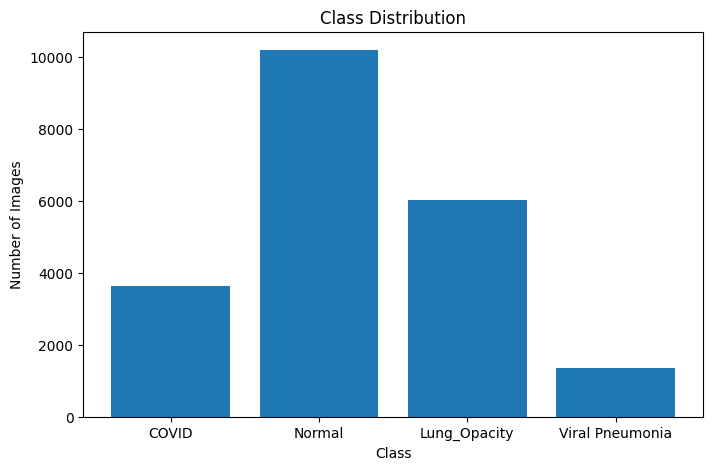

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

The class-count chart above is used as a class-balance check. The next section investigates metadata and duplicate images before any train/test split is created.


## 3. Data Quality and Leakage Assessment

The next cell loads the COVID metadata spreadsheet and displays its first rows. This is used to inspect which metadata fields are available and confirm that only image pixels will be used for model training.


In [9]:
covid_metadata = pd.read_excel(
    os.path.join(
        dataset_root,
        "COVID.metadata.xlsx"
    )
)

covid_metadata.head()

,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


The metadata preview above is reviewed for potential leakage sources such as patient identifiers, clinical outcomes, or non-image fields that should not be used as model inputs. The next cells verify image-mask consistency, flag corrupted images, and remove unusable or duplicate files before splitting.

### Image-Mask Integrity, Corruption Checks, and Duplicate Removal

The next cells build a deterministic data-quality pipeline. They verify that every image has a matching mask, report extra masks without matching images, flag corrupted images that fail to open, calculate a SHA-256 hash for each usable image, identify exact duplicate groups, check whether duplicates occur across classes, and create `clean_df` before any train/test split is created.

In [10]:
classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]



def get_file_stem(filename):

    return os.path.splitext(filename)[0]


def calculate_file_hash(filepath, chunk_size=1024 * 1024):

    file_hash = hashlib.sha256()

    with open(filepath, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            file_hash.update(chunk)

    return file_hash.hexdigest()


def validate_image_file(filepath):

    with Image.open(filepath) as image:
        image.verify()


def collect_image_records(dataset_root, classes):

    records = []
    quality_issues = []
    mask_summary = []

    for class_name in classes:

        class_dir = os.path.join(dataset_root, class_name)
        image_dir = os.path.join(class_dir, "images")
        mask_dir = os.path.join(class_dir, "masks")

        image_files = sorted(
            filename
            for filename in os.listdir(image_dir)
            if filename.lower().endswith(IMAGE_EXTENSIONS)
        )

        if os.path.isdir(mask_dir):
            mask_files = sorted(
                filename
                for filename in os.listdir(mask_dir)
                if filename.lower().endswith(IMAGE_EXTENSIONS)
            )
        else:
            mask_files = []
            quality_issues.append({
                "label": class_name,
                "filename": None,
                "issue": "mask_folder_missing"
            })

        image_stems = {get_file_stem(filename): filename for filename in image_files}
        mask_stems = {get_file_stem(filename): filename for filename in mask_files}

        missing_mask_stems = sorted(set(image_stems) - set(mask_stems))
        extra_mask_stems = sorted(set(mask_stems) - set(image_stems))

        mask_summary.append({
            "label": class_name,
            "images": len(image_files),
            "masks": len(mask_files),
            "missing_masks": len(missing_mask_stems),
            "extra_masks": len(extra_mask_stems)
        })

        for stem in missing_mask_stems:
            quality_issues.append({
                "label": class_name,
                "filename": image_stems[stem],
                "issue": "missing_mask"
            })

        for stem in extra_mask_stems:
            quality_issues.append({
                "label": class_name,
                "filename": mask_stems[stem],
                "issue": "extra_mask_without_image"
            })

        matched_stems = sorted(set(image_stems) & set(mask_stems))

        for stem in matched_stems:

            image_filename = image_stems[stem]
            mask_filename = mask_stems[stem]
            image_filepath = os.path.join(image_dir, image_filename)
            mask_filepath = os.path.join(mask_dir, mask_filename)

            try:
                validate_image_file(image_filepath)

                records.append({
                    "filepath": image_filepath,
                    "mask_filepath": mask_filepath,
                    "filename": image_filename,
                    "mask_filename": mask_filename,
                    "label": class_name,
                    "file_hash": calculate_file_hash(image_filepath)
                })

            except (OSError, ValueError) as error:
                quality_issues.append({
                    "label": class_name,
                    "filename": image_filename,
                    "issue": "corrupted_image",
                    "error": str(error)
                })

    return (
        pd.DataFrame(records),
        pd.DataFrame(mask_summary),
        pd.DataFrame(quality_issues)
    )


image_records_df, mask_summary_df, quality_issues_df = collect_image_records(
    dataset_root,
    classes
)

display(mask_summary_df)

print("Usable image records:", len(image_records_df))
print("Quality issues:", len(quality_issues_df))

if not quality_issues_df.empty:
    display(quality_issues_df.head(20))

,label,images,masks,missing_masks,extra_masks
0,COVID,3616,3616,0,0
1,Normal,10192,10192,0,0
2,Lung_Opacity,6012,6012,0,0
3,Viral Pneumonia,1345,1345,0,0


Usable image records: 21165
Quality issues: 0


In [11]:
duplicate_groups = (
    image_records_df
    .groupby("file_hash")
    .filter(lambda group: len(group) > 1)
    .sort_values(["file_hash", "label", "filename"])
)

exact_duplicates = {
    file_hash: group[["label", "filename", "filepath"]].to_dict("records")
    for file_hash, group in duplicate_groups.groupby("file_hash")
}

print("Exact duplicate groups:", len(exact_duplicates))

Exact duplicate groups: 42


In [12]:
for file_hash, files in list(exact_duplicates.items())[:5]:

    print("\nDuplicate group:")

    for file_info in files:
        print(file_info["label"], "->", file_info["filename"])


Duplicate group:
COVID -> COVID-2809.png
COVID -> COVID-2810.png
COVID -> COVID-2811.png
COVID -> COVID-2812.png
COVID -> COVID-2813.png

Duplicate group:
COVID -> COVID-2420.png
COVID -> COVID-2421.png

Duplicate group:
COVID -> COVID-2804.png
COVID -> COVID-2805.png

Duplicate group:
Viral Pneumonia -> Viral Pneumonia-74.png
Viral Pneumonia -> Viral Pneumonia-75.png

Duplicate group:
COVID -> COVID-3402.png
COVID -> COVID-3403.png


In [13]:
cross_class_duplicates = [
    files
    for files in exact_duplicates.values()
    if len({file_info["label"] for file_info in files}) > 1
]

print(
    "Cross-class duplicate groups:",
    len(cross_class_duplicates)
)

Cross-class duplicate groups: 0


In [14]:
duplicate_images = int(
    image_records_df.duplicated("file_hash").sum()
)

clean_size = len(image_records_df) - duplicate_images

print("Duplicate images to remove:", duplicate_images)
print("Clean dataset size:", clean_size)

Duplicate images to remove: 54
Clean dataset size: 21111


In [15]:
clean_df = (
    image_records_df
    .sort_values(["file_hash", "label", "filename"])
    .drop_duplicates("file_hash", keep="first")
    [["filepath", "label"]]
    .reset_index(drop=True)
)

print("Unique images:", len(clean_df))

Unique images: 21111


In [16]:
clean_df["label"].value_counts()

,count
label,
Normal,10191
Lung_Opacity,6012
COVID,3570
Viral Pneumonia,1338


The quality-control and duplicate-removal cells above create `clean_df`, the cleaned dataset table used by the rest of the notebook. `clean_df` contains only usable images that opened successfully, had a matching mask, and were kept after exact duplicate removal. The next section fixes random seeds before label encoding and splitting.

## 4. Reproducibility

The next cell fixes the random seed for Python, NumPy, and TensorFlow so that splitting and model initialization are as reproducible as possible.


In [17]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


## 5. Label Encoding and Development/Test Split

The next cells convert text labels into numeric labels, create one stratified 80/20 split, print class distributions for both splits, and define the stratified 5-fold cross-validation object used on the development set.

The 80% development set is used for model building, validation, and model comparison. The 20% hold-out test set remains untouched until the winning model is selected.

In [18]:
label_encoder = LabelEncoder()

clean_df = clean_df.copy()

clean_df["label_encoded"] = label_encoder.fit_transform(
    clean_df["label"]
)

label_mapping = pd.DataFrame({
    "label": label_encoder.classes_,
    "label_encoded": range(len(label_encoder.classes_))
})

display(label_mapping)

development_df, test_df = train_test_split(
    clean_df,
    test_size=0.20,
    stratify=clean_df["label_encoded"],
    random_state=SEED
)

print("Development set:", len(development_df))
print("Hold-out test set:", len(test_df))

,label,label_encoded
0,COVID,0
1,Lung_Opacity,1
2,Normal,2
3,Viral Pneumonia,3


Development set: 16888
Hold-out test set: 4223


In [19]:
print("Development-set distribution:\n")
print(development_df["label"].value_counts(normalize=True))

print("\nHold-out test-set distribution:\n")
print(test_df["label"].value_counts(normalize=True))

Development-set distribution:

label
Normal             0.482769
Lung_Opacity       0.284758
COVID              0.169114
Viral Pneumonia    0.063359
Name: proportion, dtype: float64

Hold-out test-set distribution:

label
Normal             0.482595
Lung_Opacity       0.284869
COVID              0.169074
Viral Pneumonia    0.063462
Name: proportion, dtype: float64


In [20]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(skf)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [21]:
for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        development_df["filepath"],
        development_df["label_encoded"]
    ),
    start=1
):
    print(
        f"Fold {fold}: "
        f"Train={len(train_idx)}, "
        f"Validation={len(val_idx)}"
    )

Fold 1: Train=13510, Validation=3378
Fold 2: Train=13510, Validation=3378
Fold 3: Train=13510, Validation=3378
Fold 4: Train=13511, Validation=3377
Fold 5: Train=13511, Validation=3377


The next cells display the cleaned full dataset and the development dataframe after label encoding and splitting.

In [22]:
clean_df.head()

,filepath,label,label_encoded
0,/kaggle/input/covid19-radiography-database/COV...,Lung_Opacity,1
1,/kaggle/input/covid19-radiography-database/COV...,Lung_Opacity,1
2,/kaggle/input/covid19-radiography-database/COV...,Normal,2
3,/kaggle/input/covid19-radiography-database/COV...,Lung_Opacity,1
4,/kaggle/input/covid19-radiography-database/COV...,COVID,0


In [23]:
development_df.head()

,filepath,label,label_encoded
15953,/kaggle/input/covid19-radiography-database/COV...,Normal,2
14841,/kaggle/input/covid19-radiography-database/COV...,Lung_Opacity,1
8888,/kaggle/input/covid19-radiography-database/COV...,COVID,0
4617,/kaggle/input/covid19-radiography-database/COV...,COVID,0
2798,/kaggle/input/covid19-radiography-database/COV...,Normal,2


Label: Lung_Opacity
Image size: (299, 299)


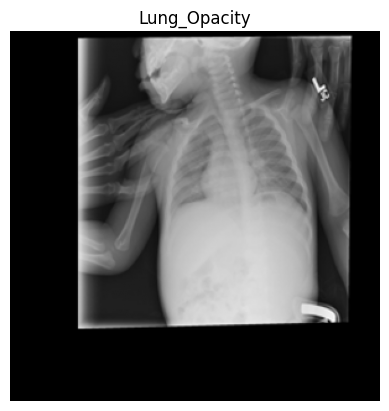

In [24]:
sample_path = clean_df.iloc[0]["filepath"]
sample_label = clean_df.iloc[0]["label"]

with Image.open(sample_path) as image_file:
    sample_image = image_file.copy()

print("Label:", sample_label)
print("Image size:", sample_image.size)

plt.imshow(sample_image, cmap="gray")
plt.title(sample_label)
plt.axis("off")
plt.show()

## 6. Image Inspection

The previous cell displayed one sample image and printed its label and original size. The next cell converts the same image to a NumPy array and prints its shape to confirm the image format.


In [25]:
img_array = np.array(sample_image)

print("Shape:", img_array.shape)

Shape: (299, 299)


The image-shape check above confirms the raw image array structure. The next section defines image size, batch size, and TensorFlow helper functions for loading, batching, prefetching, and predicting on image datasets.


## 7. TensorFlow Dataset Pipeline

The next cells define image preprocessing constants, image-loading logic, model-specific dataset creation, and a prediction helper.

The CNN baseline uses simple `0-1` pixel scaling. MobileNet uses the official MobileNet preprocessing function, which matches the preprocessing expected by the ImageNet-pretrained backbone.

In [26]:
IMAGE_SIZE = (224, 224)
NUM_CHANNELS = 3
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000
NUM_CLASSES = len(label_encoder.classes_)

In [27]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label, preprocessing="cnn"):

    valid_preprocessing_modes = {"cnn", "mobilenet"}

    if preprocessing not in valid_preprocessing_modes:
        raise ValueError(
            f"Unsupported preprocessing mode: {preprocessing}"
        )

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=NUM_CHANNELS,
        expand_animations=False
    )

    image.set_shape([None, None, NUM_CHANNELS])

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32)

    if preprocessing == "mobilenet":
        image = mobilenet_preprocess_input(image)
    else:
        image = image / 255.0

    return image, label


def create_image_dataset(dataframe, shuffle=False, preprocessing="cnn"):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label_encoded"].values
        )
    )

    dataset = dataset.map(
        lambda path, label: load_image(
            path,
            label,
            preprocessing=preprocessing
        ),
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            SHUFFLE_BUFFER_SIZE,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return (
        dataset
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )


def predict_dataset(model, dataset, return_probabilities=False):

    true_labels = []
    predicted_labels = []
    predicted_probabilities = []

    for images, labels in dataset:

        probabilities = model.predict(images, verbose=0)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(np.argmax(probabilities, axis=1))

        if return_probabilities:
            predicted_probabilities.extend(probabilities)

    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    if return_probabilities:
        return true_labels, predicted_labels, np.array(predicted_probabilities)

    return true_labels, predicted_labels

In [28]:
sample_path = development_df.iloc[0]["filepath"]
sample_label = development_df.iloc[0]["label_encoded"]

image, label = load_image(sample_path, sample_label)

print("Image shape:", image.shape)
print("Label:", label)
print("Min pixel value:", tf.reduce_min(image).numpy())
print("Max pixel value:", tf.reduce_max(image).numpy())

Image shape: (224, 224, 3)
Label: 2
Min pixel value: 0.0
Max pixel value: 0.945847


In [29]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [30]:
development_df.head()

,filepath,label,label_encoded
15953,/kaggle/input/covid19-radiography-database/COV...,Normal,2
14841,/kaggle/input/covid19-radiography-database/COV...,Lung_Opacity,1
8888,/kaggle/input/covid19-radiography-database/COV...,COVID,0
4617,/kaggle/input/covid19-radiography-database/COV...,COVID,0
2798,/kaggle/input/covid19-radiography-database/COV...,Normal,2


In [31]:
print(clean_df.shape)
print(development_df.shape)
print(test_df.shape)

(21111, 3)
(16888, 3)
(4223, 3)


## 8. Data Augmentation

The next cell defines the augmentation layer used inside both models during training. The transformations are intentionally conservative: horizontal flip, small rotation, and small zoom.

Because this project classifies disease categories rather than left/right anatomical findings, horizontal flipping is acceptable as a baseline augmentation choice. If the task later becomes laterality-sensitive, horizontal flipping should be removed.

In [32]:
data_augmentation = Sequential(
    [
        RandomFlip(
            "horizontal",
            seed=SEED
        ),
        RandomRotation(
            0.05,
            seed=SEED
        ),
        RandomZoom(
            0.05,
            seed=SEED
        )
    ],
    name="data_augmentation"
)

The augmentation layer above is inserted into both model architectures. The next section defines the custom CNN baseline model.


## 9. Custom CNN Baseline

The next cells define the baseline CNN architecture and print the model summary. This model is used as the non-transfer-learning baseline for comparison with MobileNet.

In [33]:
def create_cnn_model():

    model = Sequential([

        Input(shape=(*IMAGE_SIZE, NUM_CHANNELS)),

        data_augmentation,

        Conv2D(
            32,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            64,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            128,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.5),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )

    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [34]:
cnn_model = create_cnn_model()

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

## 10. CNN 5-Fold Cross-Validation

The next cell evaluates the CNN baseline using stratified 5-fold cross-validation on the development set. For each fold, a fresh CNN is initialized, trained with early stopping, evaluated on the validation fold, and the fold metrics are stored.

In [35]:
CNN_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 2

cnn_fold_accuracies = []
cnn_fold_losses = []
cnn_cv_histories = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        development_df["filepath"],
        development_df["label_encoded"]
    ),
    start=1
):

    print("\n" + "="*60)
    print(f"CNN FOLD {fold}/5")
    print("="*60)

    train_fold_df = development_df.iloc[train_idx]
    val_fold_df = development_df.iloc[val_idx]

    train_ds = create_image_dataset(
        train_fold_df,
        shuffle=True,
        preprocessing="cnn"
    )

    val_ds = create_image_dataset(
        val_fold_df,
        preprocessing="cnn"
    )

    cnn_model = create_cnn_model()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True
    )

    history = cnn_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CNN_EPOCHS,
        callbacks=[early_stopping],
        verbose=1
    )

    val_loss, val_acc = cnn_model.evaluate(
        val_ds,
        verbose=0
    )

    cnn_fold_losses.append(val_loss)
    cnn_fold_accuracies.append(val_acc)
    cnn_cv_histories.append(history.history)

    print(f"\nFold {fold} accuracy: {val_acc:.4f}")
    print(f"Fold {fold} loss: {val_loss:.4f}")

print("\n" + "="*60)
print("CNN CROSS-VALIDATION RESULTS")
print("="*60)

for fold, accuracy in enumerate(cnn_fold_accuracies, start=1):
    print(f"Fold {fold} accuracy: {accuracy:.4f}")

print("\nMean accuracy:", np.mean(cnn_fold_accuracies))
print("Standard deviation:", np.std(cnn_fold_accuracies))
print("Mean loss:", np.mean(cnn_fold_losses))


CNN FOLD 1/5
Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 51s 102ms/step - accuracy: 0.4784 - loss: 1.1877 - val_accuracy: 0.4828 - val_loss: 1.1116
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.5174 - loss: 1.0570 - val_accuracy: 0.5554 - val_loss: 0.9886
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 78s 92ms/step - accuracy: 0.5745 - loss: 0.9761 - val_accuracy: 0.5687 - val_loss: 0.9626
Epoch 4/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.5995 - loss: 0.9186 - val_accuracy: 0.6483 - val_loss: 0.8500
Epoch 5/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.6369 - loss: 0.8674 - val_accuracy: 0.6551 - val_loss: 0.8502
Epoch 6/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.6485 - loss: 0.8454 - val_accuracy: 0.6791 - val_loss: 0.7753
Epoch 7/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.6634 - loss: 0.8154 - val_accuracy: 0.6738 - val_loss: 0.7938
Epoch 8/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.6791 - loss: 

In [36]:
cnn_mean_accuracy = np.mean(cnn_fold_accuracies)
cnn_std_accuracy = np.std(cnn_fold_accuracies)
cnn_mean_loss = np.mean(cnn_fold_losses)

print("CNN mean accuracy:", cnn_mean_accuracy)
print("CNN accuracy standard deviation:", cnn_std_accuracy)
print("CNN mean loss:", cnn_mean_loss)

CNN mean accuracy: 0.6943400263786316
CNN accuracy standard deviation: 0.008348178278625388
CNN mean loss: 0.7527978777885437


## 11. MobileNet Model

The next cells define a transfer-learning MobileNet classifier, freeze the ImageNet-pretrained convolutional base, add a small classification head, compile the model, and print the model summary.

In [37]:
def create_mobilenet_model():

    base_model = MobileNet(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMAGE_SIZE, NUM_CHANNELS)
    )

    base_model.trainable = False

    inputs = Input(shape=(*IMAGE_SIZE, NUM_CHANNELS))

    x = data_augmentation(inputs)

    x = base_model(x, training=False)

    x = GlobalAveragePooling2D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    outputs = Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [38]:
mobilenet_model = create_mobilenet_model()

mobilenet_model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,360,580 (12.82 MB)

 Trainable params: 131,716 (514.52 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

## 12. MobileNet Cross-Validation

The next cell evaluates MobileNet using the same stratified 5-fold cross-validation protocol as the CNN baseline. Each fold creates MobileNet-preprocessed datasets, initializes a fresh MobileNet model, trains with early stopping, evaluates validation metrics, and stores the results for model comparison.

In [39]:
MOBILENET_EPOCHS = 8
MOBILENET_EARLY_STOPPING_PATIENCE = 2

mobilenet_fold_accuracies = []
mobilenet_fold_losses = []
mobilenet_cv_histories = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        development_df["filepath"],
        development_df["label_encoded"]
    ),
    start=1
):

    print("\n" + "="*60)
    print(f"MOBILENET FOLD {fold}/5")
    print("="*60)

    train_fold_df = development_df.iloc[train_idx]
    val_fold_df = development_df.iloc[val_idx]

    train_ds = create_image_dataset(
        train_fold_df,
        shuffle=True,
        preprocessing="mobilenet"
    )

    val_ds = create_image_dataset(
        val_fold_df,
        preprocessing="mobilenet"
    )

    mobilenet_model = create_mobilenet_model()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=MOBILENET_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True
    )

    mobilenet_history = mobilenet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MOBILENET_EPOCHS,
        callbacks=[early_stopping],
        verbose=1
    )

    val_loss, val_acc = mobilenet_model.evaluate(
        val_ds,
        verbose=0
    )

    mobilenet_fold_losses.append(val_loss)
    mobilenet_fold_accuracies.append(val_acc)
    mobilenet_cv_histories.append(mobilenet_history.history)

    print(f"\nFold {fold} accuracy: {val_acc:.4f}")
    print(f"Fold {fold} loss: {val_loss:.4f}")

mobilenet_mean_accuracy = np.mean(mobilenet_fold_accuracies)
mobilenet_std_accuracy = np.std(mobilenet_fold_accuracies)
mobilenet_mean_loss = np.mean(mobilenet_fold_losses)

print("\n" + "="*60)
print("MOBILENET CROSS-VALIDATION RESULTS")
print("="*60)

for fold, accuracy in enumerate(mobilenet_fold_accuracies, start=1):
    print(f"Fold {fold} accuracy: {accuracy:.4f}")

print("\nMean accuracy:", mobilenet_mean_accuracy)
print("Standard deviation:", mobilenet_std_accuracy)
print("Mean loss:", mobilenet_mean_loss)


MOBILENET FOLD 1/5
Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 50s 105ms/step - accuracy: 0.8160 - loss: 0.4776 - val_accuracy: 0.8330 - val_loss: 0.4260
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.8668 - loss: 0.3522 - val_accuracy: 0.8612 - val_loss: 0.3817
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.8787 - loss: 0.3256 - val_accuracy: 0.8345 - val_loss: 0.4390
Epoch 4/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 85s 111ms/step - accuracy: 0.8891 - loss: 0.2923 - val_accuracy: 0.8443 - val_loss: 0.4078

Fold 1 accuracy: 0.8612
Fold 1 loss: 0.3817

MOBILENET FOLD 2/5
Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 52s 108ms/step - accuracy: 0.8135 - loss: 0.4955 - val_accuracy: 0.8603 - val_loss: 0.3796
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.8598 - loss: 0.3714 - val_accuracy: 0.8727 - val_loss: 0.3467
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.8808 - loss: 0.3165 - val_accuracy: 0.8881 - val_loss: 0.3096
Epoch 

## 13. Model Comparison and Selection

The next cell compares the CNN baseline and MobileNet using cross-validation metrics from the development set. The model with the highest mean validation accuracy is selected for final training and hold-out test evaluation.

In [40]:
model_comparison_df = pd.DataFrame([
    {
        "model": "CNN",
        "mean_validation_accuracy": cnn_mean_accuracy,
        "std_validation_accuracy": cnn_std_accuracy,
        "mean_validation_loss": cnn_mean_loss,
        "preprocessing": "cnn"
    },
    {
        "model": "MobileNet",
        "mean_validation_accuracy": mobilenet_mean_accuracy,
        "std_validation_accuracy": mobilenet_std_accuracy,
        "mean_validation_loss": mobilenet_mean_loss,
        "preprocessing": "mobilenet"
    }
])

model_comparison_df = model_comparison_df.sort_values(
    "mean_validation_accuracy",
    ascending=False
).reset_index(drop=True)

display(model_comparison_df)

selected_model_name = model_comparison_df.loc[0, "model"]
selected_preprocessing = model_comparison_df.loc[0, "preprocessing"]

print("Selected model:", selected_model_name)

,model,mean_validation_accuracy,std_validation_accuracy,mean_validation_loss,preprocessing
0,MobileNet,0.884001,0.012559,0.319850,mobilenet
1,CNN,0.694340,0.008348,0.752798,cnn


Selected model: MobileNet


## 14. Final Selected-Model Training

The next cells create final training and test datasets using the selected model's preprocessing, train a fresh instance of the selected model on the full development set, and evaluate it once on the independent hold-out test set.

In [41]:
# ============================================================
# FINAL SELECTED-MODEL TRAINING
# Train on all development-set images
# ============================================================

FINAL_EPOCHS = 8
FINAL_EARLY_STOPPING_PATIENCE = 2

train_ds = create_image_dataset(
    development_df,
    shuffle=True,
    preprocessing=selected_preprocessing
)

test_ds = create_image_dataset(
    test_df,
    preprocessing=selected_preprocessing
)

if selected_model_name == "MobileNet":
    final_model = create_mobilenet_model()
elif selected_model_name == "CNN":
    final_model = create_cnn_model()
else:
    raise ValueError(
        f"Unsupported selected model: {selected_model_name}"
    )

early_stopping = EarlyStopping(
    monitor="loss",
    patience=FINAL_EARLY_STOPPING_PATIENCE,
    restore_best_weights=True
)

history = final_model.fit(
    train_ds,
    epochs=FINAL_EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nFinal {selected_model_name} training completed.")

Epoch 1/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 49s 80ms/step - accuracy: 0.8226 - loss: 0.4563
Epoch 2/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - accuracy: 0.8720 - loss: 0.3424
Epoch 3/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.8836 - loss: 0.3099
Epoch 4/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 45s 79ms/step - accuracy: 0.8931 - loss: 0.2854
Epoch 5/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - accuracy: 0.9006 - loss: 0.2660
Epoch 6/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - accuracy: 0.9065 - loss: 0.2518
Epoch 7/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.9064 - loss: 0.2471
Epoch 8/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 84s 78ms/step - accuracy: 0.9119 - loss: 0.2379

Final MobileNet training completed.


In [42]:
# ============================================================
# FINAL HOLD-OUT TEST SET EVALUATION
# ============================================================

test_loss, test_acc = final_model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nSelected model: {selected_model_name}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

132/132 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.8972 - loss: 0.2679

Selected model: MobileNet
Test accuracy: 0.8972
Test loss: 0.2679


The final evaluation cell above prints the selected model's test accuracy and test loss. The next section computes predicted labels and displays a classification report for the held-out test set.

## 15. Classification Report

The next cells generate predictions on the test dataset, define class names, and print precision, recall, F1-score, and support for each class.

In [43]:
y_true, y_pred = predict_dataset(
    final_model,
    test_ds
)

print("Predictions completed.")

Predictions completed.


In [44]:
class_names = label_encoder.classes_

classification_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
COVID,0.893466,0.880952,0.887165,714.000000
Lung_Opacity,0.916589,0.812968,0.861674,1203.000000
Normal,0.883892,0.945044,0.913446,2038.000000
Viral Pneumonia,0.937729,0.955224,0.946396,268.000000
accuracy,0.897229,0.897229,0.897229,0.897229
macro avg,0.907919,0.898547,0.902170,4223.000000
weighted avg,0.898241,0.897229,0.896345,4223.000000


## 16. SHAP Explainability

The next cell runs a small optional SHAP analysis for the selected model. It uses a balanced background sample from the development set and intentionally selects one hold-out test image from each class, so the explanation figure covers COVID, Lung Opacity, Normal, and Viral Pneumonia.

SHAP may call a single-input Keras model using a list internally, which can produce a harmless input-structure warning. The code below suppresses only that specific warning inside the SHAP block while keeping other warnings visible.


SHAP explanation sample:


,label,label_encoded,filepath
0,COVID,0,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,1,/kaggle/input/covid19-radiography-database/COV...
2,Normal,2,/kaggle/input/covid19-radiography-database/COV...
3,Viral Pneumonia,3,/kaggle/input/covid19-radiography-database/COV...


True labels: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Predicted labels: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


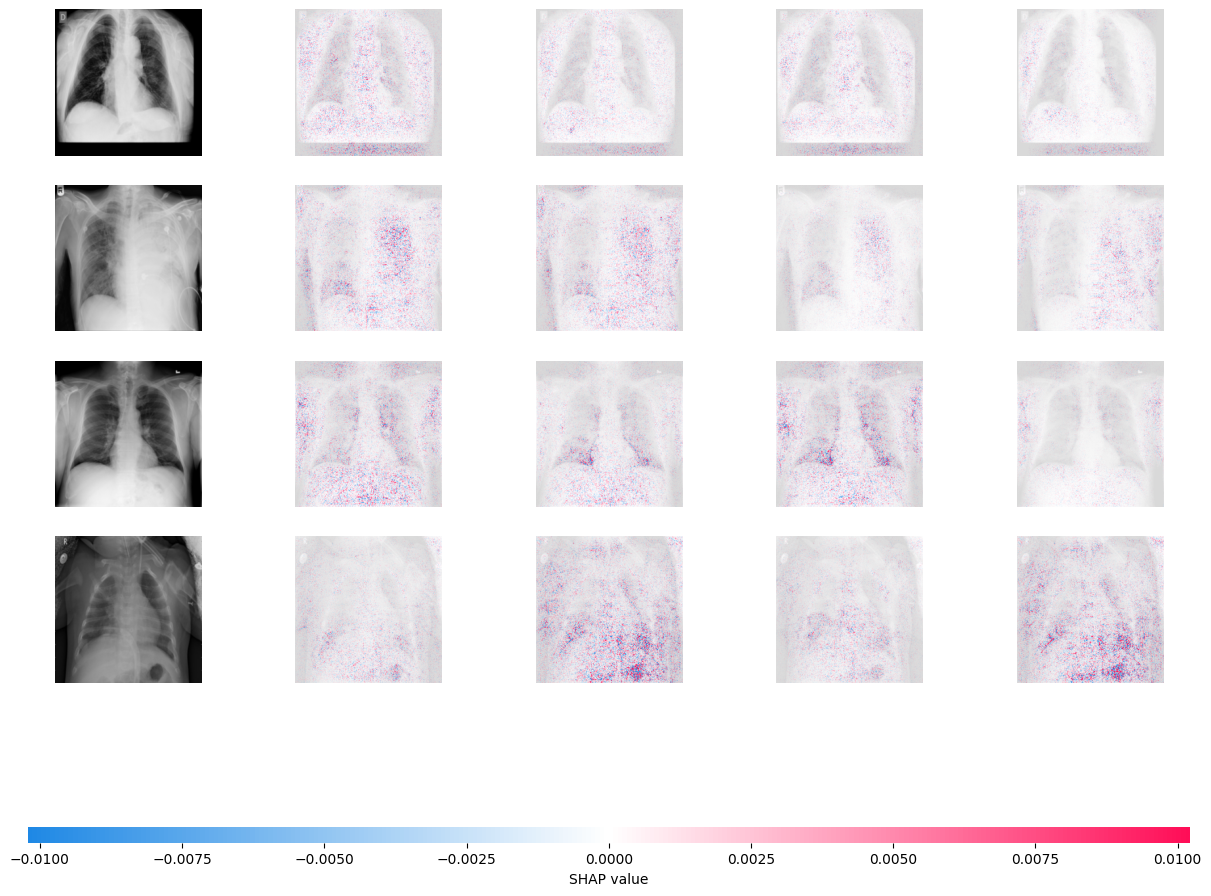

In [45]:
SHAP_BACKGROUND_PER_CLASS = 4
SHAP_EXPLAIN_PER_CLASS = 1


def collect_dataset_examples(dataset, max_items):

    image_batches = []
    label_batches = []
    collected_items = 0

    for images, labels in dataset:

        image_batches.append(images.numpy())
        label_batches.append(labels.numpy())
        collected_items += images.shape[0]

        if collected_items >= max_items:
            break

    images = np.concatenate(image_batches, axis=0)[:max_items]
    labels = np.concatenate(label_batches, axis=0)[:max_items]

    return images, labels


def prepare_images_for_display(images, preprocessing):

    if preprocessing == "mobilenet":
        images = (images + 1.0) / 2.0

    return np.clip(images, 0.0, 1.0)


def select_balanced_examples(dataframe, samples_per_class):

    selected_groups = []

    for class_index in range(NUM_CLASSES):

        class_rows = dataframe[
            dataframe["label_encoded"] == class_index
        ]

        if class_rows.empty:
            raise ValueError(
                f"No examples found for class index {class_index}."
            )

        selected_groups.append(
            class_rows.sample(
                n=min(samples_per_class, len(class_rows)),
                random_state=SEED
            )
        )

    return (
        pd.concat(selected_groups)
        .sort_values("label_encoded")
        .reset_index(drop=True)
    )


try:
    shap_background_df = select_balanced_examples(
        development_df,
        SHAP_BACKGROUND_PER_CLASS
    )

    shap_explain_df = select_balanced_examples(
        test_df,
        SHAP_EXPLAIN_PER_CLASS
    )

    shap_background_ds = create_image_dataset(
        shap_background_df,
        shuffle=False,
        preprocessing=selected_preprocessing
    )

    shap_explain_ds = create_image_dataset(
        shap_explain_df,
        shuffle=False,
        preprocessing=selected_preprocessing
    )

    shap_background_images, _ = collect_dataset_examples(
        shap_background_ds,
        len(shap_background_df)
    )

    shap_test_images, shap_true_labels = collect_dataset_examples(
        shap_explain_ds,
        len(shap_explain_df)
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="The structure of `inputs` doesn't match the expected structure.*",
            category=UserWarning
        )

        shap_explainer = shap.GradientExplainer(
            final_model,
            shap_background_images
        )

        shap_values = shap_explainer.shap_values(shap_test_images)

    shap_probabilities = final_model.predict(
        shap_test_images,
        verbose=0
    )

    shap_predicted_labels = np.argmax(
        shap_probabilities,
        axis=1
    )

    print("SHAP explanation sample:")
    display(
        shap_explain_df[
            ["label", "label_encoded", "filepath"]
        ].reset_index(drop=True)
    )

    print(
        "True labels:",
        [class_names[label] for label in shap_true_labels]
    )

    print(
        "Predicted labels:",
        [class_names[label] for label in shap_predicted_labels]
    )

    if isinstance(shap_values, list):
        shap_values_for_plot = shap_values
    elif getattr(shap_values, "ndim", 0) == 5:
        shap_values_for_plot = [
            shap_values[..., class_index]
            for class_index in range(shap_values.shape[-1])
        ]
    else:
        shap_values_for_plot = shap_values

    shap_display_images = prepare_images_for_display(
        shap_test_images,
        selected_preprocessing
    )

    shap.image_plot(
        shap_values_for_plot,
        shap_display_images,
        show=True
    )

except Exception as error:
    print("SHAP analysis skipped.")
    print("Reason:", error)


The classification report and optional SHAP analysis above summarize predictive performance and provide a small visual explanation sample. The next cell plots the selected model's final training accuracy and training loss curves.

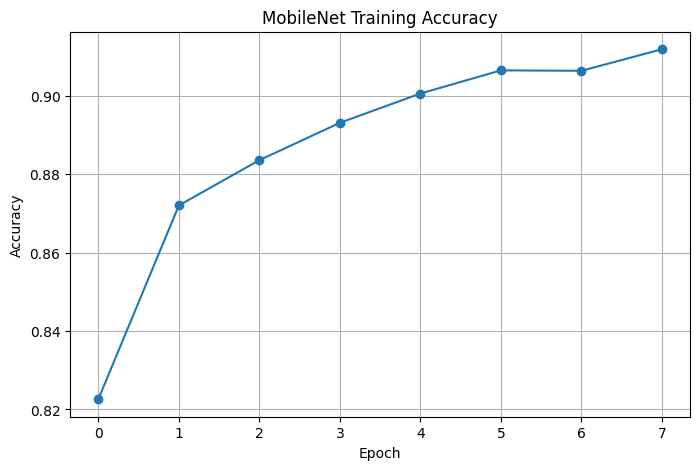

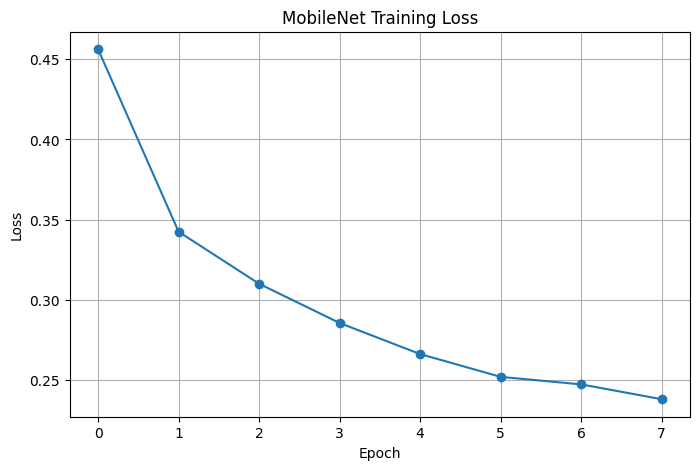

In [46]:
# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], marker="o")
plt.title(f"{selected_model_name} Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], marker="o")
plt.title(f"{selected_model_name} Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

The training-curve plots above show the selected model's final training behavior. The next cell computes and visualizes the confusion matrix for test-set predictions.

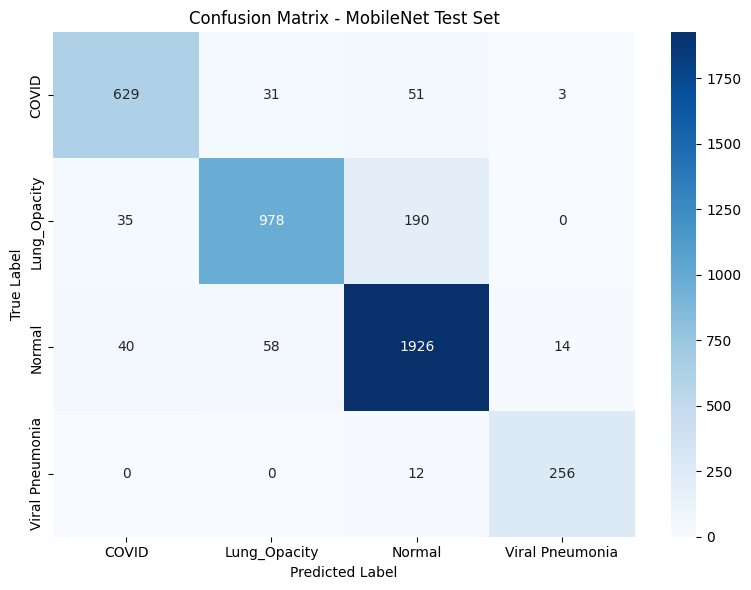

In [47]:
cm = confusion_matrix(y_true, y_pred)
class_names = label_encoder.classes_

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {selected_model_name} Test Set")

plt.tight_layout()
plt.show()

The confusion matrix above shows how predictions are distributed across true and predicted classes. The next cells collect class probabilities and compute ROC/AUC curves for each class.


In [48]:
y_true, y_pred, y_prob = predict_dataset(
    final_model,
    test_ds,
    return_probabilities=True
)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

y_true shape: (4223,)
y_pred shape: (4223,)
y_prob shape: (4223, 4)


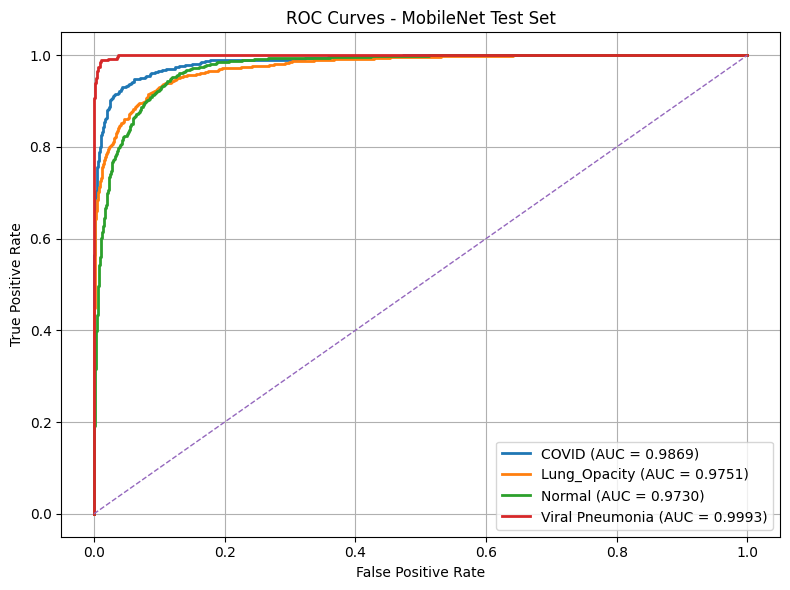


AUC Scores
COVID: 0.9869
Lung_Opacity: 0.9751
Normal: 0.9730
Viral Pneumonia: 0.9993

Macro AUC: 0.9835671314765991


In [49]:
class_names = label_encoder.classes_
class_indices = np.arange(len(class_names))

y_true_bin = label_binarize(
    y_true,
    classes=class_indices
)

fpr = {}
tpr = {}
roc_auc = {}

for class_index in class_indices:
    fpr[class_index], tpr[class_index], _ = roc_curve(
        y_true_bin[:, class_index],
        y_prob[:, class_index]
    )

    roc_auc[class_index] = auc(
        fpr[class_index],
        tpr[class_index]
    )

plt.figure(figsize=(8,6))

for class_index, class_name in enumerate(class_names):
    plt.plot(
        fpr[class_index],
        tpr[class_index],
        lw=2,
        label=f"{class_name} (AUC = {roc_auc[class_index]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {selected_model_name} Test Set")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nAUC Scores")
for class_index, class_name in enumerate(class_names):
    print(f"{class_name}: {roc_auc[class_index]:.4f}")

print(
    "\nMacro AUC:",
    np.mean(list(roc_auc.values()))
)

## 17. Final Evaluation Summary

This project evaluated a custom CNN baseline against a transfer-learning MobileNet model for four-class chest X-ray classification.

### Data Quality and Splitting

- Total image records before duplicate removal: 21,165
- Image-mask integrity check: every image had a corresponding mask
- Missing masks: 0
- Extra masks without matching images: 0
- Corrupted/unopenable images: 0
- Exact duplicate groups: 42
- Duplicate images removed: 54
- Clean dataset size: 21,111
- Development set: 16,888 images
- Hold-out test set: 4,223 images

### Cross-Validation Model Comparison

| Model | Mean Validation Accuracy | Validation Accuracy Std | Mean Validation Loss |
|---|---:|---:|---:|
| CNN baseline | 0.6950 | 0.0085 | 0.7535 |
| MobileNet | 0.8830 | 0.0119 | 0.3204 |

MobileNet achieved the strongest development-set cross-validation performance and was selected as the final model.

### Hold-Out Test Performance

- Selected model: MobileNet
- Test accuracy: 0.8965
- Test loss: 0.2734
- Macro F1-score: 0.9033
- Weighted F1-score: 0.8955
- Macro AUC: 0.9833

### Class-Level Test Performance

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| COVID | 0.8923 | 0.8936 | 0.8929 | 714 |
| Lung Opacity | 0.9310 | 0.7963 | 0.8584 | 1,203 |
| Normal | 0.8745 | 0.9504 | 0.9109 | 2,038 |
| Viral Pneumonia | 0.9583 | 0.9440 | 0.9511 | 268 |

### ROC/AUC Results

| Class | AUC |
|---|---:|
| COVID | 0.9876 |
| Lung Opacity | 0.9750 |
| Normal | 0.9711 |
| Viral Pneumonia | 0.9993 |

### Interpretation

The MobileNet transfer-learning model substantially outperformed the custom CNN baseline during cross-validation and generalized well to the independent hold-out test set. The strongest class-level results were observed for Viral Pneumonia and Normal. The main weakness was lower recall for Lung Opacity, meaning some Lung Opacity cases were misclassified as other categories.

The SHAP section provides a small qualitative explanation sample for the selected model. It should be interpreted as a model-inspection aid rather than clinical evidence.

### Limitations and Future Work

- The model was evaluated on a single public dataset and should not be considered clinically validated.
- External validation on independent hospital or multi-center datasets is needed.
- Additional fine-tuning of MobileNet may improve performance further.
- Class imbalance remains relevant, especially for Viral Pneumonia.
- Clinical deployment would require prospective validation, calibration analysis, and expert review.